In [1]:
import pandas as pd
import numpy as np
import joblib
import json
import matplotlib.pyplot as plt

from features import add_features
from constants import DATA_DIR, MODEL_DIR

In [2]:
PAIR = "MATIC/USDT"
TARGET_HORIZON = 5

symbol = PAIR.replace("/", "")
raw_path = f"{DATA_DIR}/{symbol}_5m.parquet"

# -----------------------------
# LOAD DATA
# -----------------------------
df = pd.read_parquet(raw_path).copy()
df

,open_time,open,high,low,close,volume,close_time,quote_asset_volume,num_trades,taker_buy_base_asset_volume,taker_buy_quote_asset_volume
0,2024-09-06 15:40:00+00:00,0.3662,0.3679,0.3660,0.3677,172085.1,2024-09-06 15:44:59.999000+00:00,63124.74949,184,109146.8,40004.76986
1,2024-09-06 15:45:00+00:00,0.3679,0.3683,0.3666,0.3667,236756.7,2024-09-06 15:49:59.999000+00:00,87019.72975,342,81575.3,29966.73866
2,2024-09-06 15:50:00+00:00,0.3669,0.3670,0.3655,0.3668,141178.7,2024-09-06 15:54:59.999000+00:00,51695.07204,216,90499.5,33136.56755
3,2024-09-06 15:55:00+00:00,0.3671,0.3671,0.3655,0.3663,93002.4,2024-09-06 15:59:59.999000+00:00,34067.68869,162,48157.3,17634.15575
4,2024-09-06 16:00:00+00:00,0.3661,0.3665,0.3651,0.3654,99800.5,2024-09-06 16:04:59.999000+00:00,36492.59671,207,55007.2,20111.07363
...,...,...,...,...,...,...,...,...,...,...,...
995,2024-09-10 02:35:00+00:00,0.3792,0.3795,0.3792,0.3795,40974.9,2024-09-10 02:39:59.999000+00:00,15539.65095,49,5926.1,2247.67975
996,2024-09-10 02:40:00+00:00,0.3793,0.3797,0.3792,0.3794,11745.2,2024-09-10 02:44:59.999000+00:00,4456.31620,64,5438.3,2063.61656
997,2024-09-10 02:45:00+00:00,0.3795,0.3796,0.3792,0.3794,28190.1,2024-09-10 02:49:59.999000+00:00,10695.38621,80,13511.5,5128.56960
998,2024-09-10 02:50:00+00:00,0.3794,0.3796,0.3791,0.3792,12248.0,2024-09-10 02:54:59.999000+00:00,4645.79767,50,5669.3,2151.02044


In [ ]:
# -----------------------------
# CONFIG
# -----------------------------
PAIR = "XRP/USDT"
TARGET_HORIZON = 5

symbol = PAIR.replace("/", "")
raw_path = f"{DATA_DIR}/{symbol}_1m.parquet"
meta_path = f"{MODEL_DIR}/rf/{symbol}__h{TARGET_HORIZON}_meta.json"

# -----------------------------
# LOAD DATA
# -----------------------------
df = pd.read_parquet(raw_path).copy()
df["date"] = pd.to_datetime(df["open_time"], utc=True)

# -----------------------------
# CREATE TARGET (CRITICAL)
# -----------------------------
df["future_return"] = (
    df["close"].shift(-TARGET_HORIZON) / df["close"] - 1
)

# -----------------------------
# FEATURES + PREDICTIONS
# -----------------------------
feat_df, _ = add_features(df, target_horizon=TARGET_HORIZON)

with open(meta_path) as f:
    meta = json.load(f)

model = joblib.load(meta["model_path"])
with open(meta["feature_cols_path"]) as f:
    feature_cols = json.load(f)

feat_df = feat_df.dropna(subset=feature_cols)

feat_df["pred"] = model.predict(feat_df[feature_cols])

In [28]:
feat_df["future_return"].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])

count    284601.000000
mean         -0.000007
std           0.002731
min          -0.364000
1%           -0.006129
5%           -0.003247
50%           0.000000
95%           0.003232
99%           0.006528
max           0.349779
Name: future_return, dtype: float64

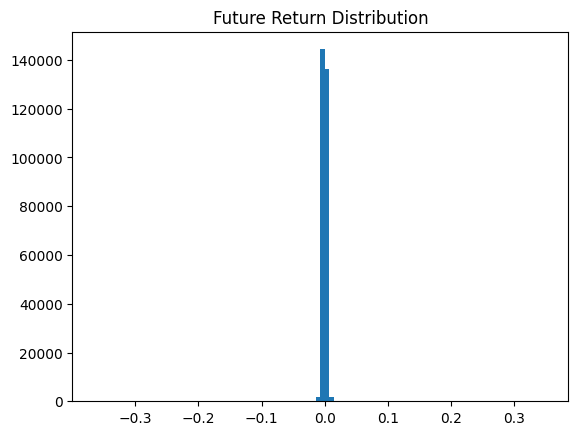

In [29]:
plt.hist(feat_df["future_return"], bins=100)
plt.title("Future Return Distribution")
plt.show()

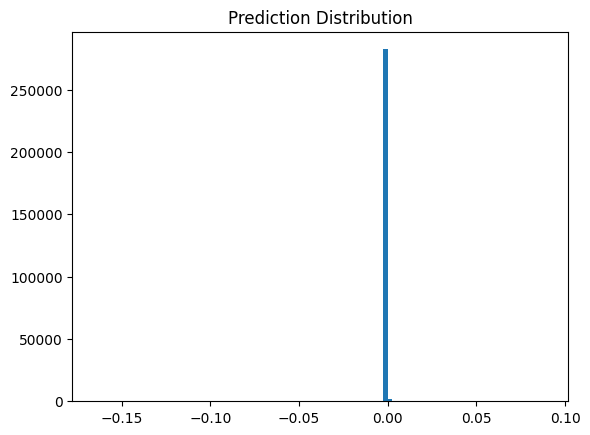

In [30]:
plt.hist(feat_df["pred"], bins=100)
plt.title("Prediction Distribution")
plt.show()

In [31]:
feat_df["pred"].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])

count    284606.000000
mean         -0.000019
std           0.000953
min          -0.165057
1%           -0.000096
5%           -0.000055
50%          -0.000020
95%          -0.000017
99%           0.000057
max           0.089173
Name: pred, dtype: float64

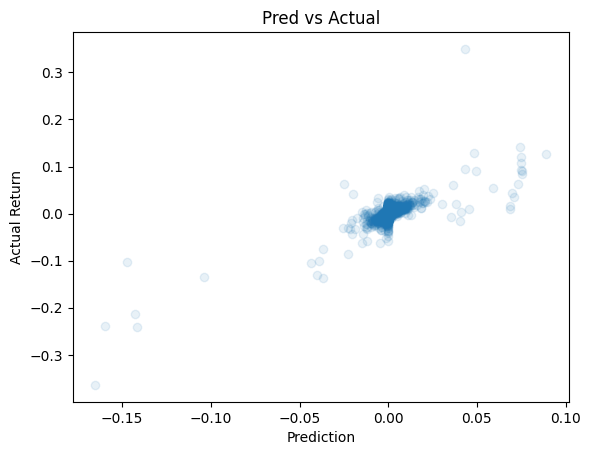

In [32]:
plt.scatter(feat_df["pred"], feat_df["future_return"], alpha=0.1)
plt.xlabel("Prediction")
plt.ylabel("Actual Return")
plt.title("Pred vs Actual")
plt.show()

In [33]:
feat_df[["pred", "future_return"]].corr()

,pred,future_return
pred,1.000000,0.516395
future_return,0.516395,1.000000


In [34]:
threshold = feat_df["pred"].abs().rolling(500).quantile(0.8)

signals = feat_df["pred"] > threshold

print("Signal rate:", signals.mean())

print(
    feat_df.loc[signals, "future_return"].mean(),
    feat_df.loc[~signals, "future_return"].mean()
)

Signal rate: 0.010126279839497411
0.0038570470240272695 -4.6163892298498434e-05


In [35]:
for h in [1, 3, 5, 10, 20]:
    df[f"ret_{h}"] = df["close"].shift(-h) / df["close"] - 1
    print(h, df[["pred", f"ret_{h}"]].corr().iloc[0,1])

KeyError: "['pred'] not in index"